In [86]:
import pickle

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import nolds
from sklearn.metrics import mutual_info_score

In [88]:
def performance_measure(original, predicted,plot = False):
    original = np.array(original)
    predicted = np.array(predicted)
    mse = np.mean((original - predicted) ** 2)
    def psd_mf_compute(x):
        n = len(x)
        fft_vals = np.fft.rfft(x,n)
        psd = np.abs(fft_vals)**2
        freqs = np.fft.rfftfreq(n)
        mean_freq = np.sum(freqs[1:] * psd[1:]) / np.sum(psd[1:])  
        return psd, mean_freq

    def ami_1stm_compute(x, max_lag=100, bins=64):
        # Discretize data into bins
        _, bin_edges = np.histogram(x, bins=bins)
        digitized = np.digitize(x, bin_edges[:-1])
    
        ami = []
        for lag in range(1, max_lag):
            x1 = digitized[:-lag]
            x2 = digitized[lag:]
            mi = mutual_info_score(x1, x2)
            ami.append(mi)
        
        # Find the first local minimum
        for i in range(1, len(ami) - 1):
            if ami[i] < ami[i-1] and ami[i] < ami[i+1]:
                return ami,i + 1  # +1 because lag starts at 1
            
        return ami, np.argmin(ami) + 1 # fallback if no local min
    
    
    psd_o,mf_o = psd_mf_compute(original)
    min_tsep_o = int(round(1/mf_o))
    ami_o,lag_o = ami_1stm_compute(original,bins = 100)
    le_o = nolds.lyap_r(original,min_tsep=min_tsep_o,lag=lag_o)

    psd_p,mf_p = psd_mf_compute(predicted)
    min_tsep_p = int(round(1/mf_p))
    ami_p,lag_p = ami_1stm_compute(predicted,bins = 100)
    le_p = nolds.lyap_r(predicted,min_tsep=min_tsep_p,lag=lag_p)

    psd_o = np.array(psd_o)
    psd_p = np.array(psd_p)
    ami_o = np.array(ami_o) 
    ami_p = np.array(ami_p)
    mse_psd = np.mean((psd_o-psd_p)**2)

    if plot :
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        n = len(original)
        freqs = np.fft.rfftfreq(len(original))
        plt.plot(freqs[1:n//10], psd_o[1:n//10],label='Original PSD')
        plt.plot(freqs[1:n//10], psd_p[1:n//10],label='Predicted PSD')
        plt.xlabel("Frequency (Hz)")
        plt.title('Power Spectral Density')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(ami_o, label='Original AMI')
        plt.plot(ami_p, label='Predicted AMI')
        plt.title('Average Mutual Information')
        plt.legend()

        plt.show()
    return mse, le_o, le_p, lag_o, lag_p,mse_psd    

In [89]:
def MG_generate_interp(gamma=0.1,beta=0.2,tau=60,theta=1,n=10,x0=1,N=2000000,delta=0.01):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)+0.1
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    x_delta = MG_rk4(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  T,X = T[::100],X[::100]
  return T,X

In [92]:
_, X_200 = MG_generate_interp(tau = 200)
true_200  = []
for  i in range (100):
    true_200.append(X_200[(12000+10*i):(13536+10*i)])

In [93]:
_, X_60 = MG_generate_interp(tau = 60)
true_60  = []
for  i in range (100):
    true_60.append(X_60[(12000+10*i):(13536+10*i)])

In [94]:
with open('LSTM_chaos_test.pkl', 'rb') as f:
    LSTM_pred, _ = pickle.load(f)

In [96]:
with open('TTM_chaos_test.pkl', 'rb') as f:
    TTM_pred = pickle.load(f)

In [97]:
with open('TTM_5_chaos_test.pkl', 'rb') as f:
    TTM_5_pred = pickle.load(f)

In [98]:
with open('TTM_dege_chaos_test.pkl', 'rb') as f:
    TTM_dege_pred = pickle.load(f)

In [99]:
with open('TTM_chaos_test_200.pkl', 'rb') as f:
    TTM_pred_200 = pickle.load(f)

In [100]:
with open('TTM_5_chaos_test_200.pkl', 'rb') as f:
    TTM_5_pred_200 = pickle.load(f)

In [101]:
with open('TTM_dege_chaos_test_200.pkl', 'rb') as f:
    TTM_dege_pred_200 = pickle.load(f)

In [102]:
combined_data = {
    'true_60': true_60,
    'LSTM_pred': LSTM_pred,
    'TTM_pred': TTM_pred,
    'TTM_5_pred': TTM_5_pred,
    'TTM_short_pred': TTM_dege_pred,
    'true_200': true_200,
    'TTM_pred_200': TTM_pred_200,
    'TTM_5_pred_200': TTM_5_pred_200,
    'TTM_short_pred_200': TTM_dege_pred_200
}

# Store the combined data in a pickle file
with open('combined_data.pkl', 'wb') as f:
    pickle.dump(combined_data, f)

# $\tau = 60$

## LSTM

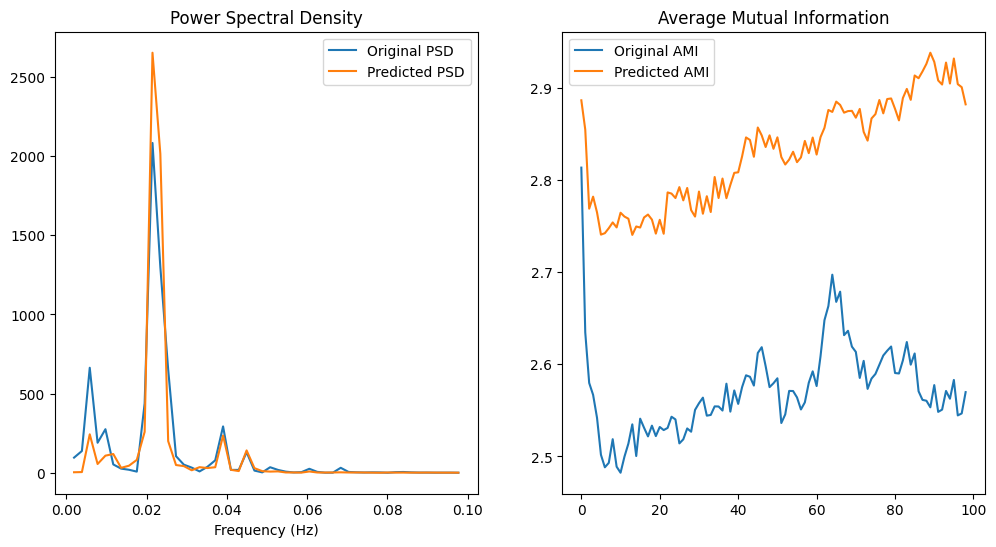

LSTM MSE: 0.14661844378870068
mse of le difference: 0.00044803477200942626
mse of lag difference: 6.79
mean of psd difference: 3615008.0972860814


In [103]:
mses_LSTM = []
le_os = []
le_ps_LSTM = []
lag_os = []
lag_ps_LSTM = []
mse_psds_LSTM = []
for i in range(100):
    original = true_60[i].flatten()[-512:]
    predicted = LSTM_pred[i].flatten()[-512:]
    plot = False
    if (i==20):
        plot = True
    mse, le_o, le_p, lag_o, lag_p,mse_psd = performance_measure(original, predicted,plot)
    mses_LSTM.append(mse)
    le_os.append(le_o)
    le_ps_LSTM.append(le_p)
    lag_os.append(lag_o)
    lag_ps_LSTM.append(lag_p)
    mse_psds_LSTM.append(mse_psd)
print('LSTM MSE:',np.mean(np.array(mses_LSTM)))  
print('mse of le difference:',np.mean((np.array(le_ps_LSTM)-np.array(le_os))**2))  
print('mse of lag difference:',np.mean((np.array(lag_ps_LSTM)-np.array(lag_os))**2))
print('mean of psd difference:',np.mean(np.mean(mse_psds_LSTM)))

## TTM

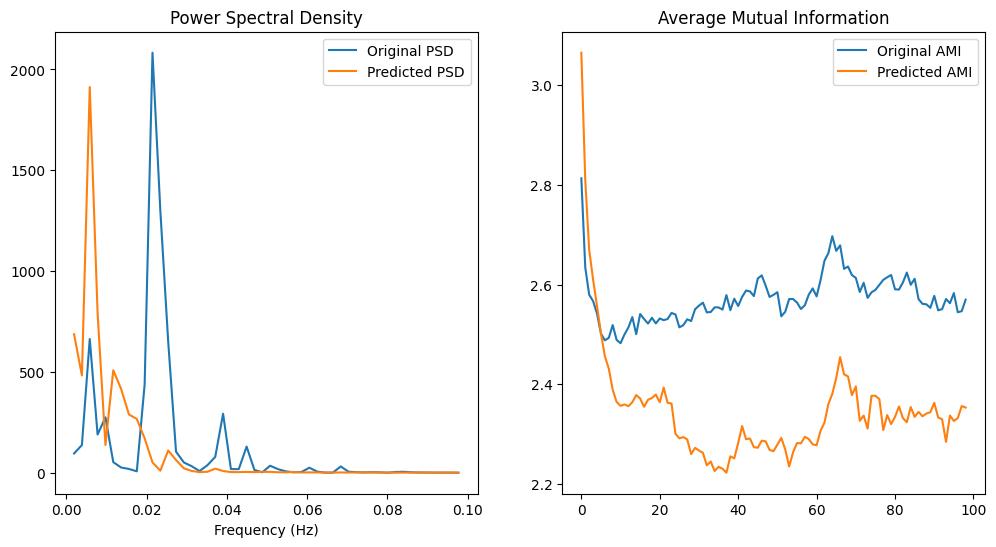

LSTM MSE: 0.11023286142521656
mse of le difference: 9.340365790912953e-05
mse of lag difference: 14.01
mean of psd difference: 2329732.316730753


In [104]:
mses_TTM = []
le_os = []
le_ps_TTM = []
lag_os = []
lag_ps_TTM = []
mse_psds_TTM = []
for i in range(100):
    original = true_60[i].flatten()[-512:]
    predicted = TTM_pred[i].flatten()[-512:]
    plot = False
    if (i==20):
        plot = True
    mse, le_o, le_p, lag_o, lag_p,mse_psd = performance_measure(original, predicted,plot)
    mses_TTM.append(mse)
    le_os.append(le_o)
    le_ps_TTM.append(le_p)
    lag_os.append(lag_o)
    lag_ps_TTM.append(lag_p)
    mse_psds_TTM.append(mse_psd)
print('LSTM MSE:',np.mean(np.array(mses_TTM)))  
print('mse of le difference:',np.mean((np.array(le_ps_TTM)-np.array(le_os))**2))  
print('mse of lag difference:',np.mean((np.array(lag_ps_TTM)-np.array(lag_os))**2))
print('mean of psd difference:',np.mean(np.mean(mse_psds_TTM)))

## TTM_5

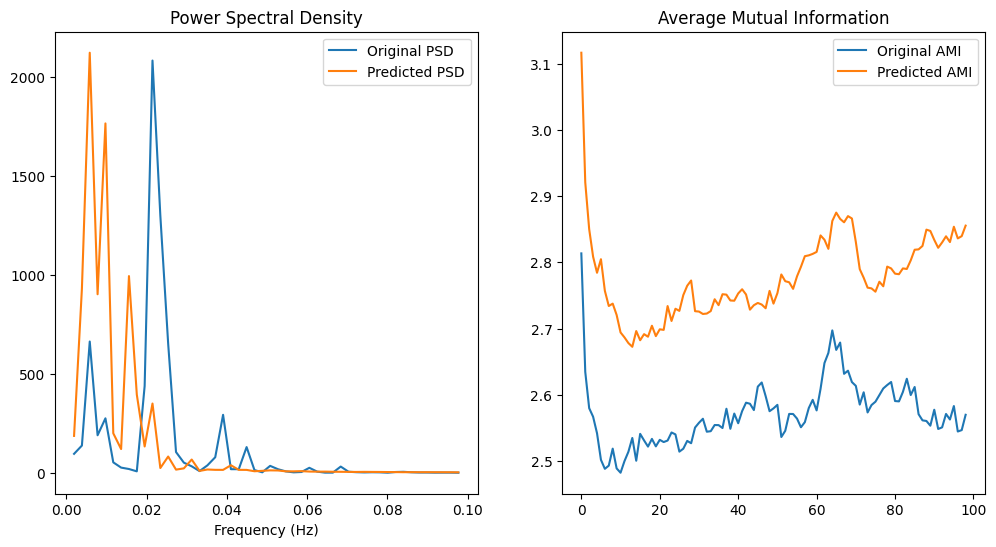

LSTM MSE: 0.12771145694248906
mse of le difference: 0.0001111546068076538
mse of lag difference: 9.18
mean of psd difference: 2956421.5516626644


In [105]:
mses_TTM_5 = []
le_os = []
le_ps_TTM_5 = []
lag_os = []
lag_ps_TTM_5 = []
mse_psds_TTM_5 = []
for i in range(100):
    original = true_60[i].flatten()[-512:]
    predicted = TTM_5_pred[i].flatten()[-512:]
    plot = False
    if (i==20):
        plot = True
    mse, le_o, le_p, lag_o, lag_p,mse_psd = performance_measure(original, predicted,plot)
    mses_TTM_5.append(mse)
    le_os.append(le_o)
    le_ps_TTM_5.append(le_p)
    lag_os.append(lag_o)
    lag_ps_TTM_5.append(lag_p)
    mse_psds_TTM_5.append(mse_psd)
print('LSTM MSE:',np.mean(np.array(mses_TTM_5)))  
print('mse of le difference:',np.mean((np.array(le_ps_TTM_5)-np.array(le_os))**2))  
print('mse of lag difference:',np.mean((np.array(lag_ps_TTM_5)-np.array(lag_os))**2))
print('mean of psd difference:',np.mean(np.mean(mse_psds_TTM_5)))

## TTM_short

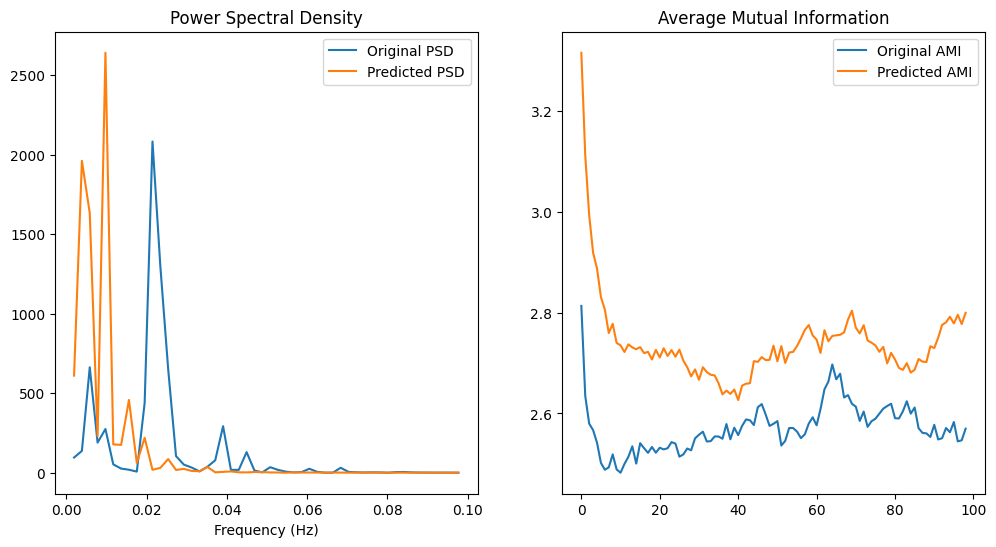

LSTM MSE: 0.11610712134945671
mse of le difference: 0.00010662796321596963
mse of lag difference: 9.98
mean of psd difference: 2404143.1528936415


In [106]:
mses_TTM_dege = []
le_os = []
le_ps_TTM_dege = []
lag_os = []
lag_ps_TTM_dege = []
mse_psds_TTM_dege = []
for i in range(100):
    original = true_60[i].flatten()[-512:]
    predicted = TTM_dege_pred[i].flatten()[-512:]
    plot = False
    if (i==20):
        plot = True
    mse, le_o, le_p, lag_o, lag_p,mse_psd = performance_measure(original, predicted,plot)
    mses_TTM_dege.append(mse)
    le_os.append(le_o)
    le_ps_TTM_dege.append(le_p)
    lag_os.append(lag_o)
    lag_ps_TTM_dege.append(lag_p)
    mse_psds_TTM_dege.append(mse_psd)
print('LSTM MSE:',np.mean(np.array(mses_TTM_dege)))  
print('mse of le difference:',np.mean((np.array(le_ps_TTM_dege)-np.array(le_os))**2))  
print('mse of lag difference:',np.mean((np.array(lag_ps_TTM_dege)-np.array(lag_os))**2))
print('mean of psd difference:',np.mean(np.mean(mse_psds_TTM_dege)))

# $\tau = 200$

## TTM

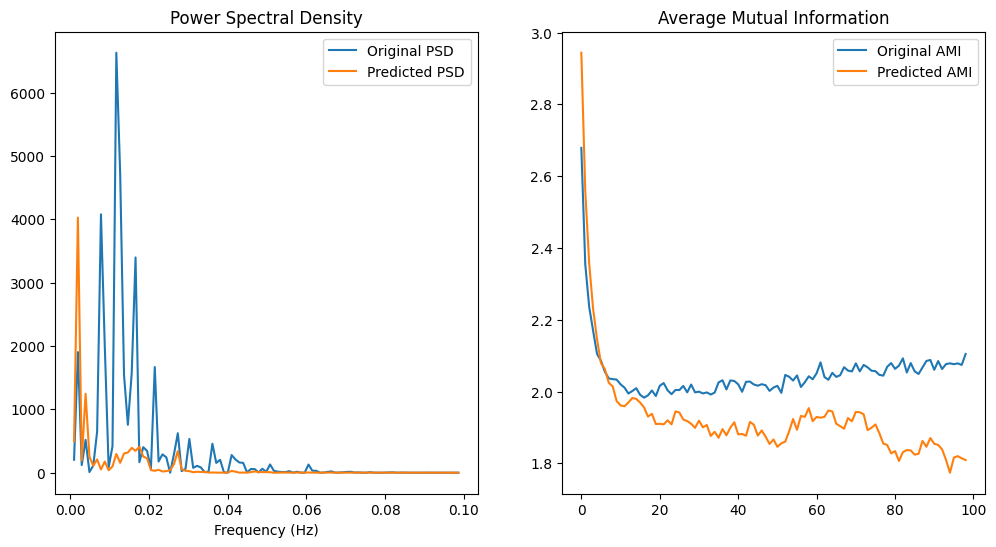

TTM MSE: 0.08170380976281821
mse of le difference: 0.00017711418756634294
mse of lag difference: 15.92
mean of psd difference: 109410731.18623476


In [107]:
mses_TTM_200 = []
le_os_200 = []
le_ps_TTM_200 = []
lag_os_200 = []
lag_ps_TTM_200 = []
mse_psds_TTM_200 = []
for i in range(100):
    original = true_200[i].flatten()[-1024:]
    predicted = TTM_pred_200[i].flatten()[-1024:]
    plot = False
    if (i==20):
        plot = True
    mse, le_o, le_p, lag_o, lag_p,mse_psd = performance_measure(original, predicted,plot)
    mses_TTM_200.append(mse)
    le_os_200.append(le_o)
    le_ps_TTM_200.append(le_p)
    lag_os_200.append(lag_o)
    lag_ps_TTM_200.append(lag_p)
    mse_psds_TTM_200.append(mse_psd)
print('TTM MSE:',np.mean(np.array(mses_TTM_200)))  
print('mse of le difference:',np.mean((np.array(le_ps_TTM_200)-np.array(le_os_200))**2))  
print('mse of lag difference:',np.mean((np.array(lag_ps_TTM_200)-np.array(lag_os_200))**2))
print('mean of psd difference:',np.mean(np.mean(mse_psds_TTM_200)))

## TTM_5

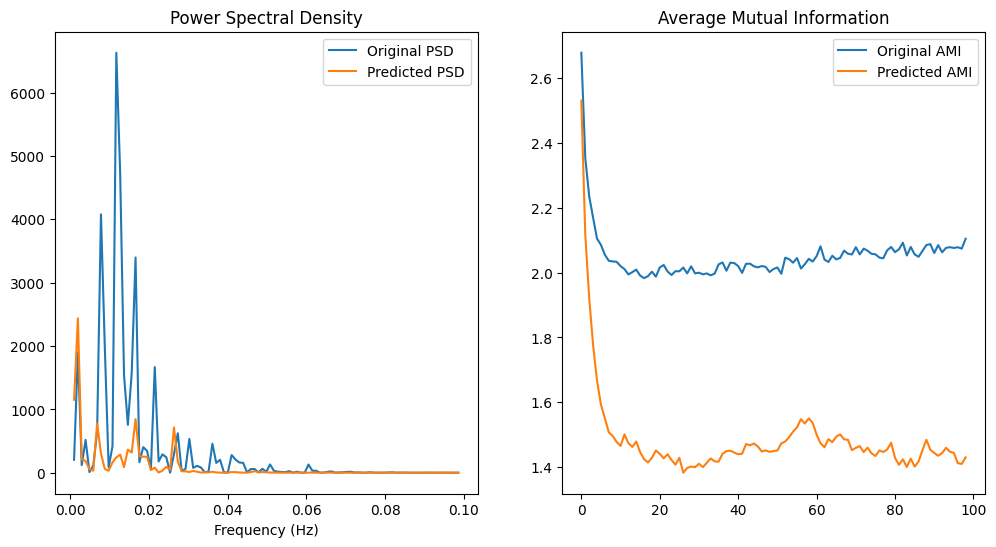

TTM_5 MSE: 0.09167860396478733
mse of le difference: 0.00014759745963218666
mse of lag difference: 14.53
mean of psd difference: 151203002.83733365


In [108]:
mses_TTM_5_200 = []
le_os_200 = []
le_ps_TTM_5_200 = []
lag_os_200 = []
lag_ps_TTM_5_200 = []
mse_psds_TTM_5_200 = []
for i in range(100):
    original = true_200[i].flatten()[-1024:]
    predicted = TTM_5_pred_200[i].flatten()[-1024:]
    plot = False
    if (i==20):
        plot = True
    mse, le_o, le_p, lag_o, lag_p,mse_psd = performance_measure(original, predicted,plot)
    mses_TTM_5_200.append(mse)
    le_os_200.append(le_o)
    le_ps_TTM_5_200.append(le_p)
    lag_os_200.append(lag_o)
    lag_ps_TTM_5_200.append(lag_p)
    mse_psds_TTM_5_200.append(mse_psd)
print('TTM_5 MSE:',np.mean(np.array(mses_TTM_5_200)))  
print('mse of le difference:',np.mean((np.array(le_ps_TTM_5_200)-np.array(le_os_200))**2))  
print('mse of lag difference:',np.mean((np.array(lag_ps_TTM_5_200)-np.array(lag_os_200))**2))
print('mean of psd difference:',np.mean(np.mean(mse_psds_TTM_5_200)))

## TTM_short

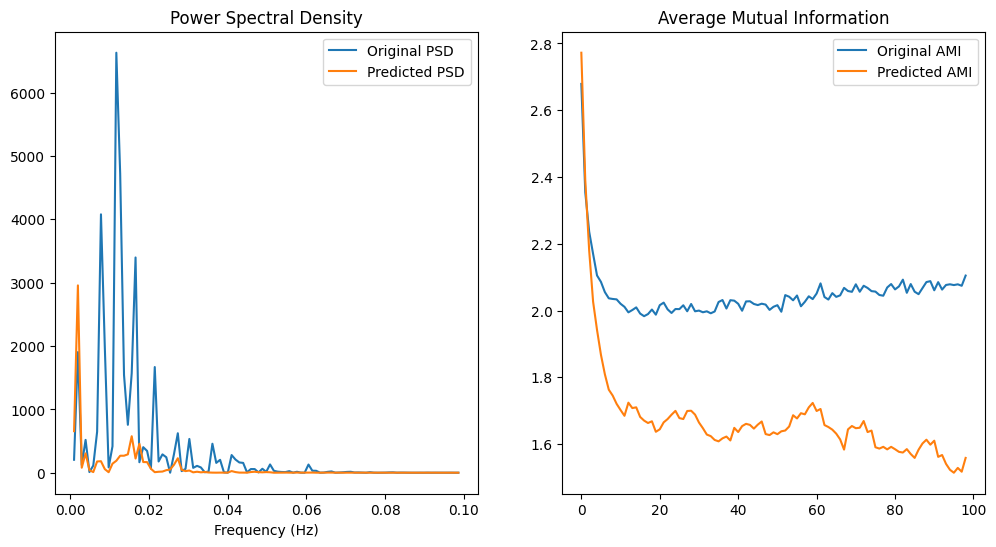

TTM_short MSE: 0.08247948680238448
mse of le difference: 0.0002075268398811673
mse of lag difference: 19.37
mean of psd difference: 118146788.56094158


In [109]:
mses_TTM_short_200 = []
le_os_200 = []
le_ps_TTM_short_200 = []
lag_os_200 = []
lag_ps_TTM_short_200 = []
mse_psds_TTM_short_200 = []
for i in range(100):
    original = true_200[i].flatten()[-1024:]
    predicted = TTM_dege_pred_200[i].flatten()[-1024:]
    plot = False
    if (i==20):
        plot = True
    mse, le_o, le_p, lag_o, lag_p,mse_psd = performance_measure(original, predicted,plot)
    mses_TTM_short_200.append(mse)
    le_os_200.append(le_o)
    le_ps_TTM_short_200.append(le_p)
    lag_os_200.append(lag_o)
    lag_ps_TTM_short_200.append(lag_p)
    mse_psds_TTM_short_200.append(mse_psd)
print('TTM_short MSE:',np.mean(np.array(mses_TTM_short_200)))  
print('mse of le difference:',np.mean((np.array(le_ps_TTM_short_200)-np.array(le_os_200))**2))  
print('mse of lag difference:',np.mean((np.array(lag_ps_TTM_short_200)-np.array(lag_os_200))**2))
print('mean of psd difference:',np.mean(np.mean(mse_psds_TTM_short_200)))

## white noise

/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/pyth

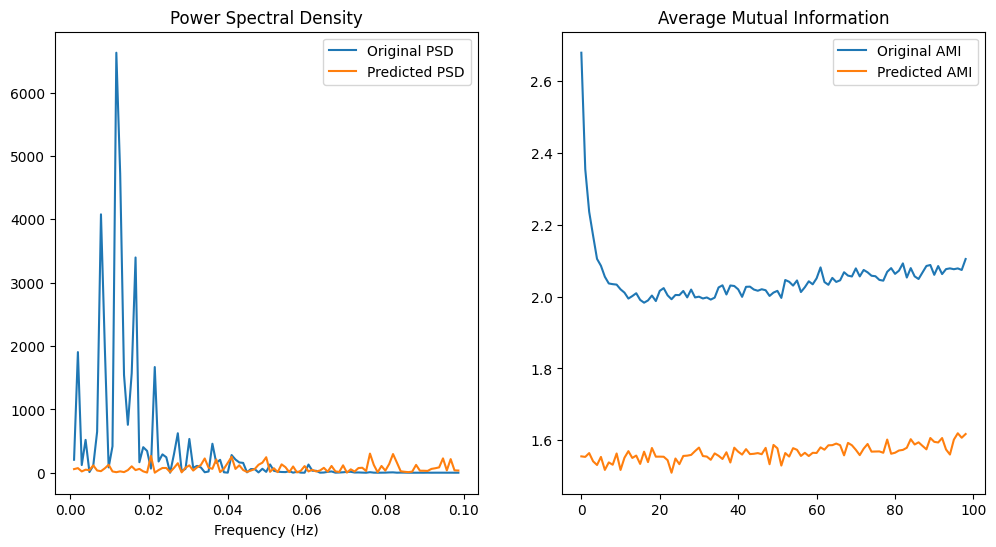

/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/liuzeyang/Projects/TTMs_try/TTMTvenv/lib/pyth

wn MSE: 0.1408446376326376
mse of le difference: 0.00041041485976027047
mse of lag difference: 43.37
mean of psd difference: 724224.6220784633


In [125]:
mses_wn_200 = []
le_os_200 = []
le_ps_wn_200 = []
lag_os_200 = []
lag_ps_wn_200 = []
mse_psds_wn_200 = []
for i in range(100):
    original = true_200[i].flatten()[-1024:]
    predicted = np.random.normal(np.mean(original),np.std(original),len(original))
    plot = False
    if (i==20):
        plot = True
    mse, le_o, le_p, lag_o, lag_p,mse_psd = performance_measure(original, predicted,plot)
    mses_wn_200.append(mse)
    le_os_200.append(le_o)
    le_ps_wn_200.append(le_p)
    lag_os_200.append(lag_o)
    lag_ps_wn_200.append(lag_p)
    mse_psds_wn_200.append(mse_psd)
print('wn MSE:',np.mean(np.array(mses_wn_200)))  
print('mse of le difference:',np.mean((np.array(le_ps_wn_200)-np.array(le_os_200))**2))  
print('mse of lag difference:',np.mean((np.array(lag_ps_wn_200)-np.array(lag_os_200))**2))
print('mean of psd difference:',np.mean(np.mean(mse_psds_wn_200)))

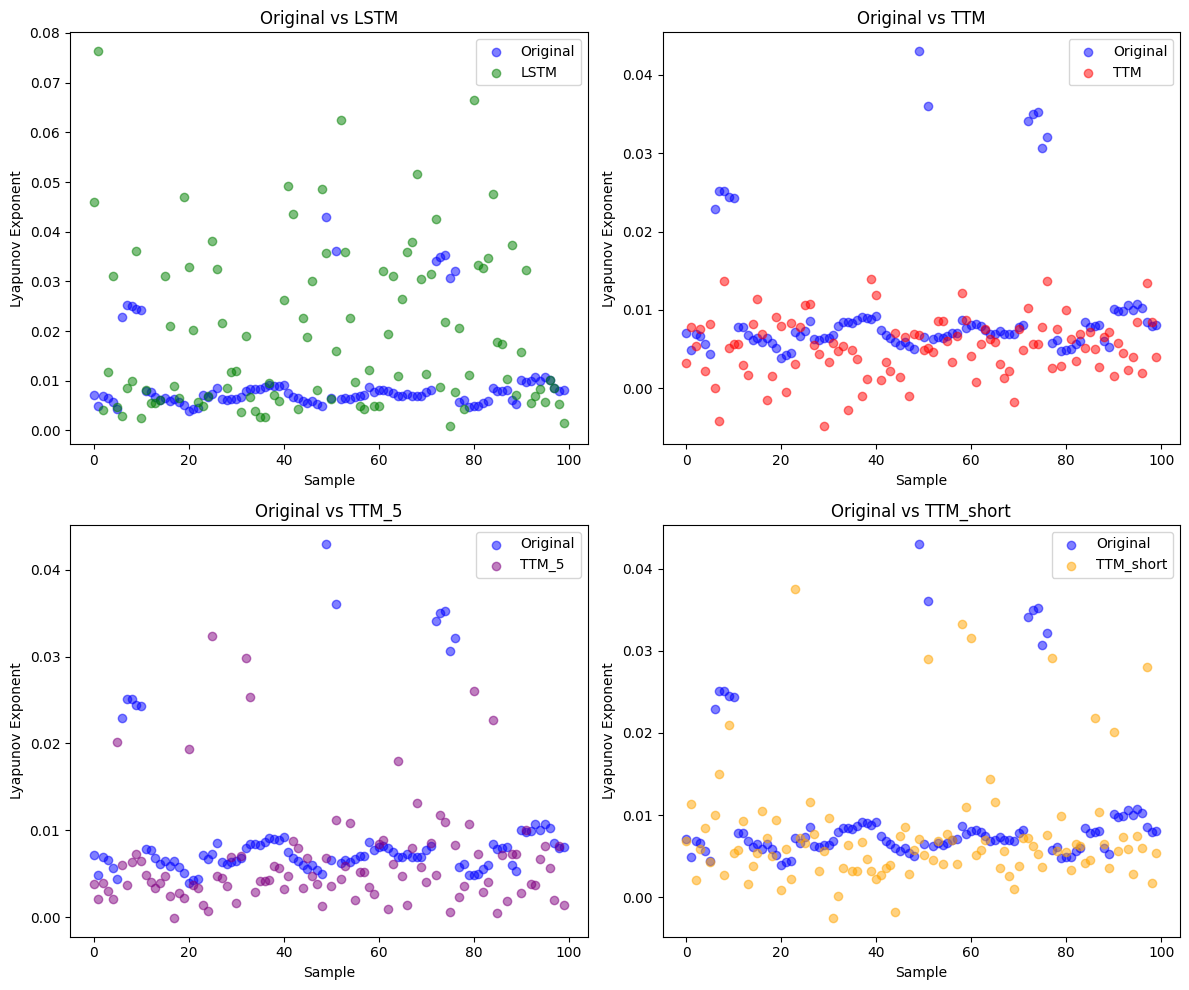

In [120]:
import matplotlib.pyplot as plt

# Assuming you have the data in le_os, le_ps_LSTM, etc.
# Each of these variables should contain the predicted values (e.g., le_ps_LSTM) and the true values (e.g., le_os)

# Create a figure with subplots for 4 separate scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# First plot: Original vs LSTM
axes[0, 0].scatter(range(len(le_os)), le_os, label='Original', color='blue', alpha=0.5)
axes[0, 0].scatter(range(len(le_ps_LSTM)), le_ps_LSTM, label='LSTM', color='green', alpha=0.5)
axes[0, 0].set_title('Original vs LSTM')
axes[0, 0].set_xlabel('Sample')
axes[0, 0].set_ylabel('Lyapunov Exponent')
axes[0, 0].legend()

# Second plot: Original vs TTM
axes[0, 1].scatter(range(len(le_os)), le_os, label='Original', color='blue', alpha=0.5)
axes[0, 1].scatter(range(len(le_ps_TTM)), le_ps_TTM, label='TTM', color='red', alpha=0.5)
axes[0, 1].set_title('Original vs TTM')
axes[0, 1].set_xlabel('Sample')
axes[0, 1].set_ylabel('Lyapunov Exponent')
axes[0, 1].legend()

# Third plot: Original vs TTM_5
axes[1, 0].scatter(range(len(le_os)), le_os, label='Original', color='blue', alpha=0.5)
axes[1, 0].scatter(range(len(le_ps_TTM_5)), le_ps_TTM_5, label='TTM_5', color='purple', alpha=0.5)
axes[1, 0].set_title('Original vs TTM_5')
axes[1, 0].set_xlabel('Sample')
axes[1, 0].set_ylabel('Lyapunov Exponent')
axes[1, 0].legend()

# Fourth plot: Original vs TTM_short
axes[1, 1].scatter(range(len(le_os)), le_os, label='Original', color='blue', alpha=0.5)
axes[1, 1].scatter(range(len(le_ps_TTM_dege)), le_ps_TTM_dege, label='TTM_short', color='orange', alpha=0.5)
axes[1, 1].set_title('Original vs TTM_short')
axes[1, 1].set_xlabel('Sample')
axes[1, 1].set_ylabel('Lyapunov Exponent')
axes[1, 1].legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


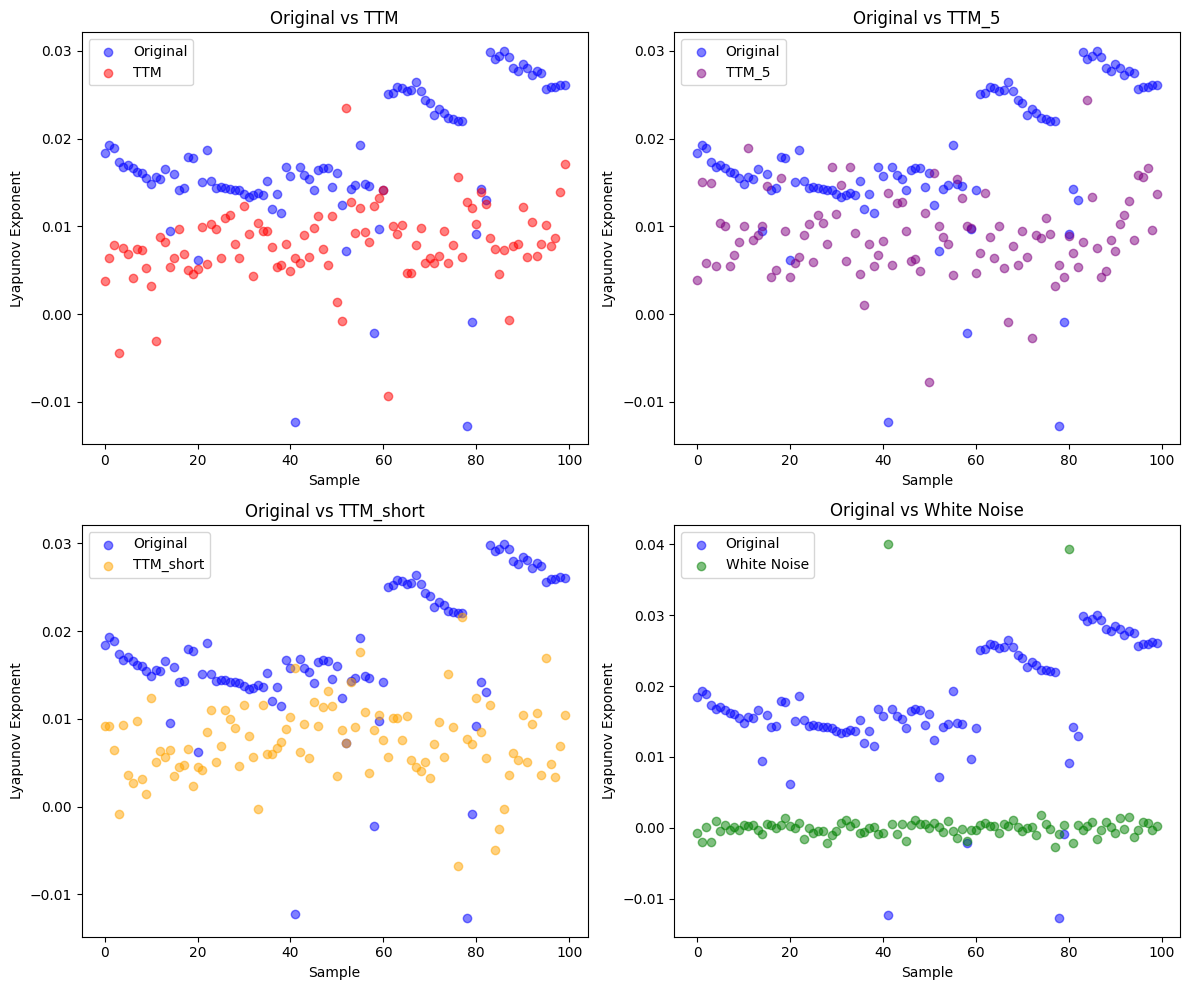

In [136]:
import matplotlib.pyplot as plt

# Assuming you have the data in le_os, le_ps_LSTM, etc.
# Each of these variables should contain the predicted values (e.g., le_ps_LSTM) and the true values (e.g., le_os)

# Create a figure with subplots for 4 separate scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Second plot: Original vs TTM
axes[0, 0].scatter(range(len(le_os_200)), le_os_200, label='Original', color='blue', alpha=0.5)
axes[0, 0].scatter(range(len(le_ps_TTM_200)), le_ps_TTM_200, label='TTM', color='red', alpha=0.5)
axes[0, 0].set_title('Original vs TTM')
axes[0, 0].set_xlabel('Sample')
axes[0, 0].set_ylabel('Lyapunov Exponent')
axes[0, 0].legend()

# Third plot: Original vs TTM_5
axes[0, 1].scatter(range(len(le_os_200)), le_os_200, label='Original', color='blue', alpha=0.5)
axes[0, 1].scatter(range(len(le_ps_TTM_5_200)), le_ps_TTM_5_200, label='TTM_5', color='purple', alpha=0.5)
axes[0, 1].set_title('Original vs TTM_5')
axes[0, 1].set_xlabel('Sample')
axes[0, 1].set_ylabel('Lyapunov Exponent')
axes[0, 1].legend()

# Fourth plot: Original vs TTM_short
axes[1, 0].scatter(range(len(le_os_200)), le_os_200, label='Original', color='blue', alpha=0.5)
axes[1, 0].scatter(range(len(le_ps_TTM_short_200)), le_ps_TTM_short_200, label='TTM_short', color='orange', alpha=0.5)
axes[1, 0].set_title('Original vs TTM_short')
axes[1, 0].set_xlabel('Sample')
axes[1, 0].set_ylabel('Lyapunov Exponent')
axes[1, 0].legend()

# Fourth plot: Original vs TTM_short
axes[1, 1].scatter(range(len(le_os_200)), le_os_200, label='Original', color='blue', alpha=0.5)
axes[1, 1].scatter(range(len(le_ps_wn_200)), le_ps_wn_200, label='White Noise', color='green', alpha=0.5)
axes[1, 1].set_title('Original vs White Noise')
axes[1, 1].set_xlabel('Sample')
axes[1, 1].set_ylabel('Lyapunov Exponent')
axes[1, 1].legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()
